##Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42

##Load Dataset

In [ ]:
file_path = "/content/drive/My Drive/Flight_Delay_Project/flights.csv"
df = pd.read_csv(file_path, low_memory=False)

# Convert numeric columns
numeric_cols = ['DISTANCE','DEPARTURE_TIME','DAY','MONTH','ARRIVAL_DELAY']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sample subset for faster execution
df = df.sample(n=500000, random_state=RANDOM_STATE)

# Create target column
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

# Selected features
features = ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','DISTANCE','DEPARTURE_TIME','DAY','MONTH']
df_model = df[features + ['DELAYED']].dropna()

# Peak hour feature
df_model['PEAK_HOUR'] = df_model['DEPARTURE_TIME'].between(700,900).astype(int)

# Convert categorical features to category dtype
categorical_cols = ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT']
for col in categorical_cols:
    df_model[col] = df_model[col].astype('category')

###EDA

##Peak hour vs Non-peak

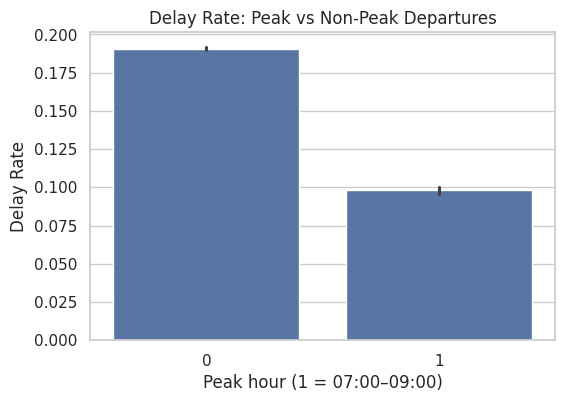

In [ ]:
# Peak hour vs non-peak delay rate
plt.figure(figsize=(6,4))
sns.barplot(x='PEAK_HOUR', y='DELAYED', data=df_model)
plt.title("Delay Rate: Peak vs Non-Peak Departures")
plt.xlabel("Peak hour (1 = 07:00–09:00)")
plt.ylabel("Delay Rate")
plt.show()

##Distribution of Arrival Delays

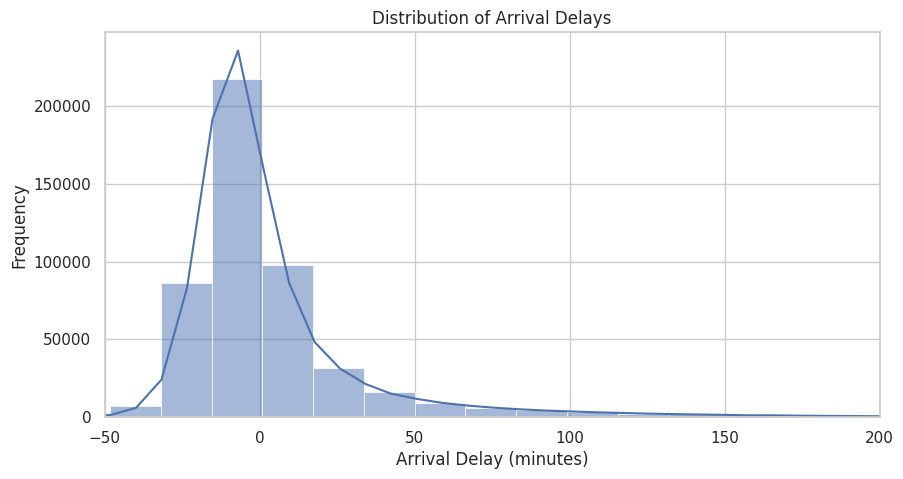

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['ARRIVAL_DELAY'], bins=100, kde=True)
plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

# Monthly delay rate

/tmp/ipykernel_2419/3839150857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_delay_rate.index, y=monthly_delay_rate.values, palette="viridis")


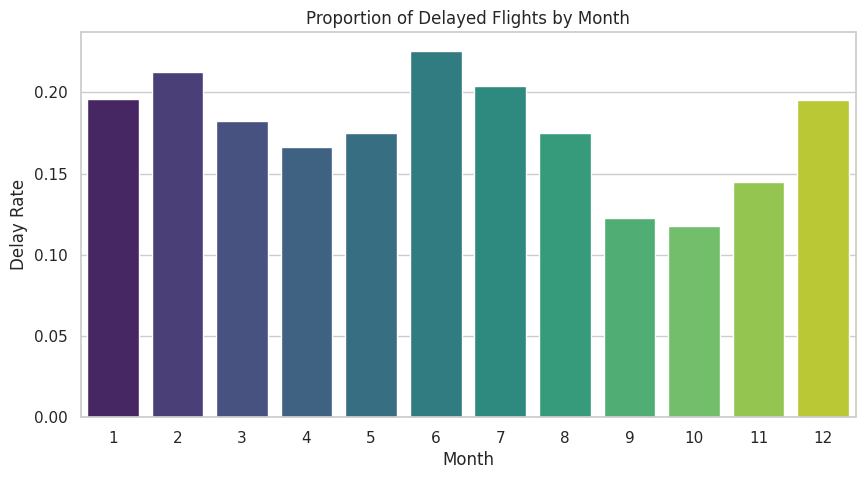

In [ ]:

monthly_delay_rate = df.groupby('MONTH')['DELAYED'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_delay_rate.index, y=monthly_delay_rate.values, palette="viridis")
plt.title("Proportion of Delayed Flights by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.show()
##Delay rates vary by month
#Summer and winter months have higher delays
#Fall months have lower delays
#Seasonality exists
#MONTH is a meaningful feature

# Airline delay rate (top 15)

/tmp/ipykernel_2419/3774291678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delay.index, y=airline_delay.values, palette="magma")


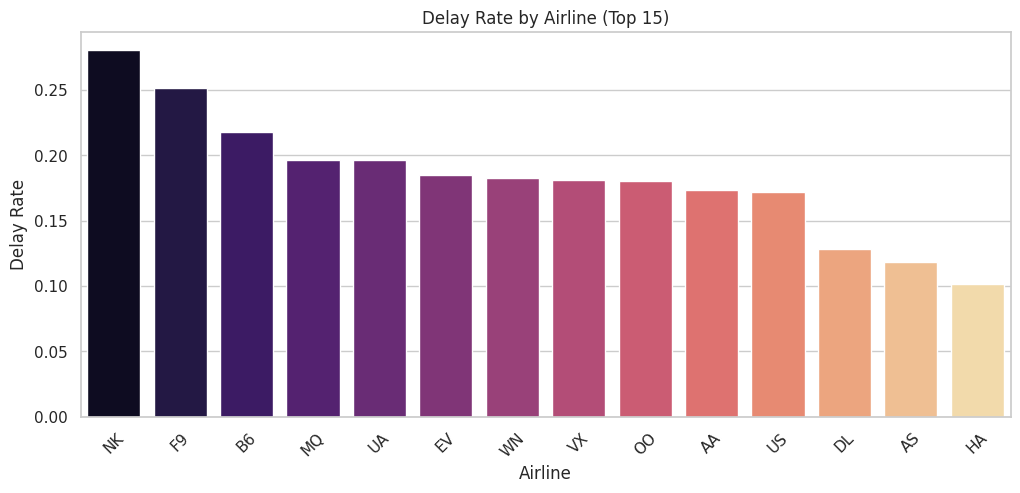

In [ ]:

airline_delay = df.groupby('AIRLINE')['DELAYED'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,5))
sns.barplot(x=airline_delay.index, y=airline_delay.values, palette="magma")
plt.title("Delay Rate by Airline (Top 15)")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.show()
#so delay depends on airline alsoooo

##Train and test data

In [ ]:
X = df_model.drop('DELAYED', axis=1)
y = df_model['DELAYED']
# Encode categorical features using LabelEncoder for tree-based models
X_encoded = X.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

#Model Training

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    predictions[name] = (y_pred, y_proba)

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": roc
    })

    print(f"\n {name} Results")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df


 Logistic Regression Results
Accuracy: 0.8207869540210441
ROC-AUC: 0.6479630464816917
              precision    recall  f1-score   support

           0       0.82      1.00      0.90    121300
           1       0.00      0.00      0.00     26485

    accuracy                           0.82    147785
   macro avg       0.41      0.50      0.45    147785
weighted avg       0.67      0.82      0.74    147785



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Random Forest Results
Accuracy: 0.6379131846939812
ROC-AUC: 0.6985410936614093
              precision    recall  f1-score   support

           0       0.89      0.64      0.74    121300
           1       0.28      0.64      0.39     26485

    accuracy                           0.64    147785
   macro avg       0.58      0.64      0.57    147785
weighted avg       0.78      0.64      0.68    147785


 Gradient Boosting Results
Accuracy: 0.8255709307439862
ROC-AUC: 0.6957669226199528
              precision    recall  f1-score   support

           0       0.83      1.00      0.90    121300
           1       0.79      0.04      0.07     26485

    accuracy                           0.83    147785
   macro avg       0.81      0.52      0.49    147785
weighted avg       0.82      0.83      0.75    147785



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:32:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Results
Accuracy: 0.8269242480630646
ROC-AUC: 0.7131096999795028
              precision    recall  f1-score   support

           0       0.83      1.00      0.90    121300
           1       0.76      0.05      0.09     26485

    accuracy                           0.83    147785
   macro avg       0.79      0.52      0.50    147785
weighted avg       0.82      0.83      0.76    147785



,Model,Accuracy,ROC-AUC
3,XGBoost,0.826924,0.713110
1,Random Forest,0.637913,0.698541
2,Gradient Boosting,0.825571,0.695767
0,Logistic Regression,0.820787,0.647963


#  ROC Curve Comparison

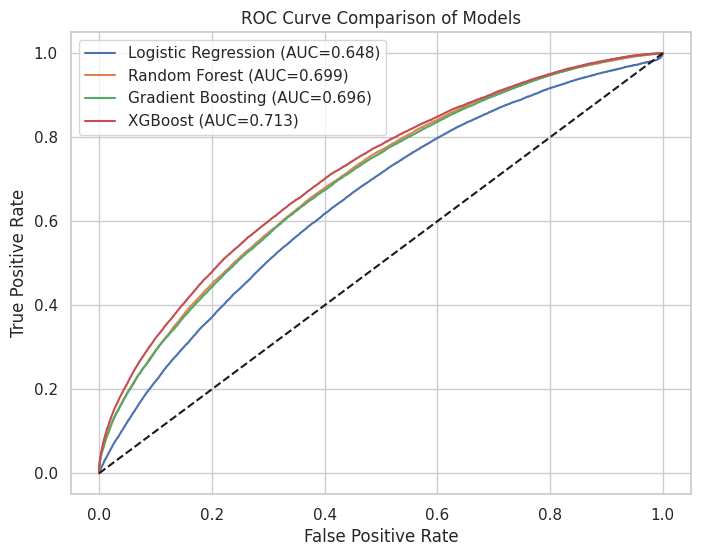

In [ ]:
plt.figure(figsize=(8,6))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, predictions[name][1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

## Confusion Matrix for Best Model (by ROC-AUC)


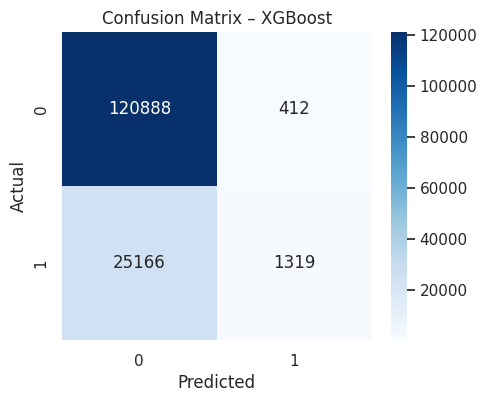

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_y_pred = predictions[best_model_name][0]

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()
#Very good at identifying on-time flights
# Poor at detecting delays at current threshold

# Feature Importance – Clean Individual Charts

/tmp/ipykernel_2419/165723244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


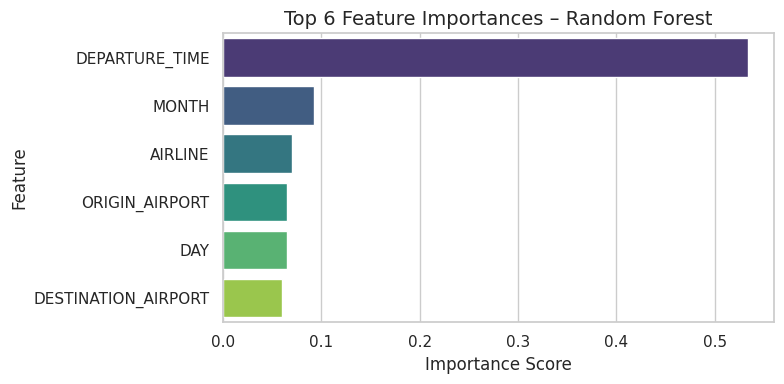

/tmp/ipykernel_2419/165723244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


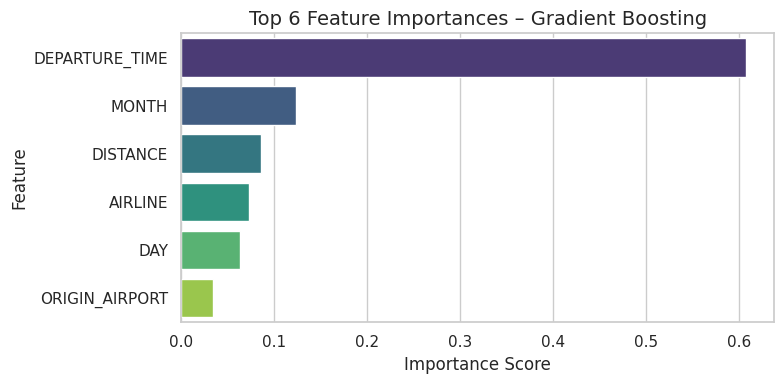

/tmp/ipykernel_2419/165723244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


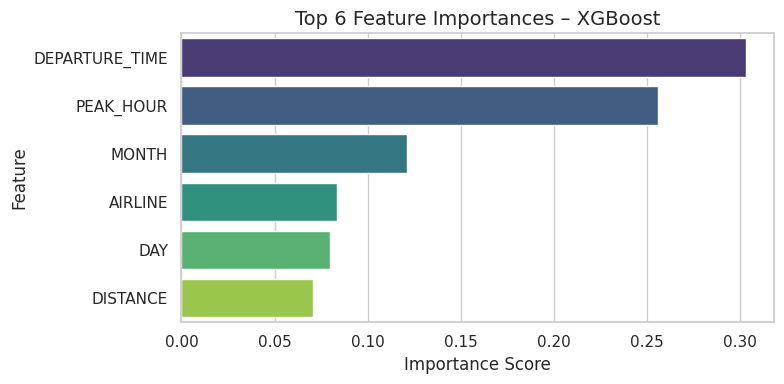

In [ ]:
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
top_n = 6  # Only show top 6 features for clarity

for name in tree_models:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        # Get top N features
        feat_importance = pd.Series(model.feature_importances_, index=X.columns)
        top_features = feat_importance.sort_values(ascending=False).head(top_n)

        # Plot
        plt.figure(figsize=(8,4))
        sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
        plt.title(f"Top {top_n} Feature Importances – {name}", fontsize=14)
        plt.xlabel("Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

# Advanced Modeling & Interpretability (XGBoost Tuning)

In [ ]:
!pip install shap --quiet
import shap

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define hyperparameter grid for XGBoost
xgb_params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb, xgb_params,
    n_iter=10, cv=3,
    scoring='roc_auc',
    verbose=1,
    random_state=RANDOM_STATE
)

xgb_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.15, 'colsample_bytree': 0.8}


##Train Final Optimized XGBoost Model

In [ ]:
# # Train XGBoost with best parameters
# xgb_opt = xgb_search.best_estimator_

# y_pred_xgb = xgb_opt.predict(X_test)
# y_proba_xgb = xgb_opt.predict_proba(X_test)[:,1]

# acc_xgb = accuracy_score(y_test, y_pred_xgb)
# roc_xgb = roc_auc_score(y_test, y_proba_xgb)

# print("Optimized XGBoost - Accuracy:", acc_xgb)
# print("Optimized XGBoost - ROC-AUC:", roc_xgb)

# Train XGBoost with best parameters and class weighting
xgb_opt = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=9,        # Increases 'ones' by prioritizing delayed flights
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_opt.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

##Compare ROC Curves (All Models)

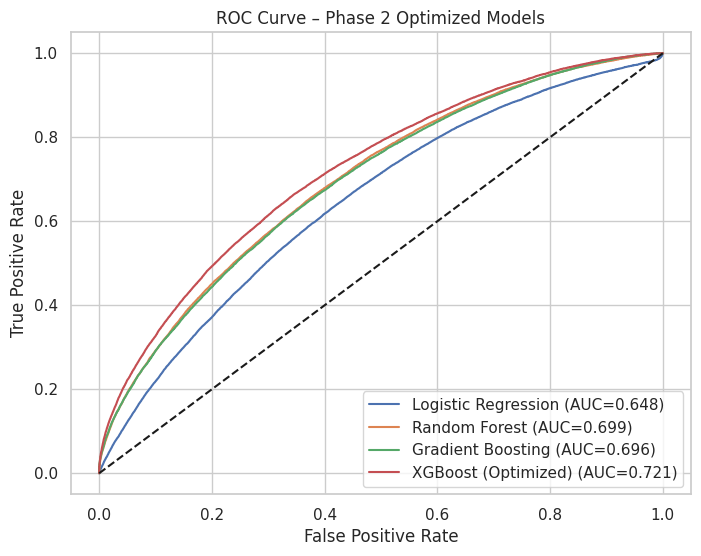

In [ ]:
plt.figure(figsize=(8,6))

model_list = [
    ('Logistic Regression', models['Logistic Regression']),
    ('Random Forest', models['Random Forest']),
    ('Gradient Boosting', models['Gradient Boosting']),
    ('XGBoost (Optimized)', xgb_opt)
]

for name, model in model_list:
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Phase 2 Optimized Models")
plt.legend()
plt.show()

Confusion Matrix – Best Model


=== Threshold 0.7 ===


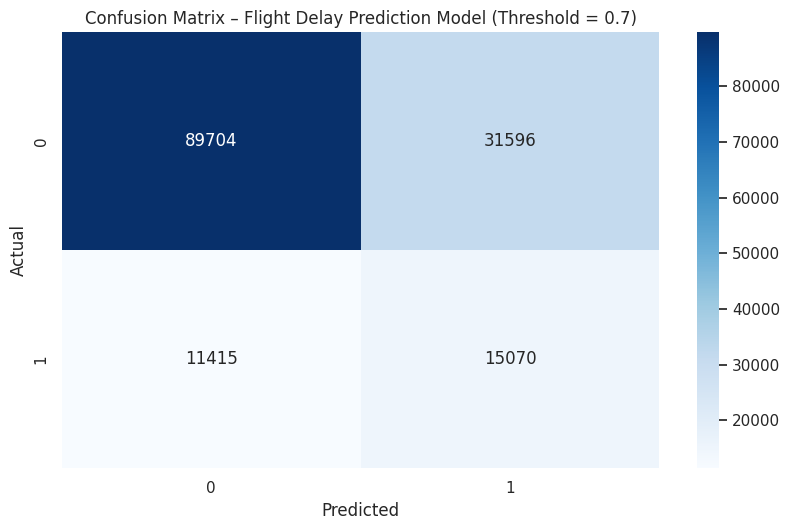

In [ ]:
y_probs = xgb_opt.predict_proba(X_test)[:, 1]
thresholds = [0.7]
plt.figure(figsize=(16, 10))
for i, t in enumerate(thresholds):
    y_pred_new = (y_probs > t).astype(int)
    cm = confusion_matrix(y_test, y_pred_new)
    plt.subplot(2, 2, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix – Flight Delay Prediction Model (Threshold = {t})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    print(f"\n=== Threshold {t} ===")
    # print(classification_report(y_test, y_pred_new))
plt.tight_layout()
plt.show()

##Top Features – Clean Bar Plot

/tmp/ipykernel_8360/42679595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.head(top_n).values, y=feat_importance.head(top_n).index, palette="viridis")


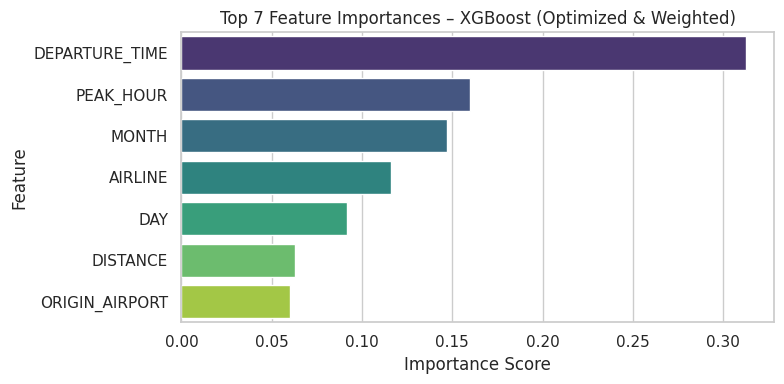

In [ ]:
# Feature importance from XGBoost
feat_importance = pd.Series(xgb_opt.feature_importances_, index=X.columns).sort_values(ascending=False)
top_n = 7

plt.figure(figsize=(8,4))
sns.barplot(x=feat_importance.head(top_n).values, y=feat_importance.head(top_n).index, palette="viridis")
plt.title(f"Top {top_n} Feature Importances – {best_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()